In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from collections import Counter
from PIL import Image,ImageEnhance,ImageOps
from tqdm import tqdm
import zipfile
import shutil
from PIL import Image
import seaborn as sns
import gc
import wandb

In [2]:
print(os.getcwd())
my_dir = os.getcwd()
zip_file_path = os.path.join(my_dir, "archive.zip")
extract_path = os.path.join(my_dir, "raw-img")  # cleaner and safer



C:\Users\42190\PycharmProjects\NS_jupyter_2


In [3]:
print(my_dir)

C:\Users\42190\PycharmProjects\NS_jupyter_2


In [4]:
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(my_dir)
    print("Extraction complete.")

Extraction complete.


<h1>   Extrahovanie Kategórií </h1>

In [5]:
def get_image_counts(base_path):
    image_counts = defaultdict(int)
    for root, dirs, files in os.walk(base_path):
        if files:  # Only count if there are images in the folder
            # Remove the base_path from the root to get the relative path
            category = root.replace(base_path, "").strip(os.sep)
            # Remove the "raw-img" part if it exists in the category name
            #category = category.replace("raw-img", "").strip(os.sep)
            image_counts[category] += len(files)
    return image_counts

# Fixing the path
base_path = os.path.join(my_dir, extract_path)  # Using os.path.join to combine paths
print(base_path)
print(my_dir)
print(extract_path)
# Get image counts for all sub-subfolders
image_counts = get_image_counts(base_path)

# Remove the first key (subfolders) as per your comment
first_key = next(iter(image_counts))
#image_counts.pop(first_key)

categories = sorted(image_counts.keys())

print(categories)
# Display category image counts
print("\nImage counts per category (including sub-subfolders):")
for cat, count in image_counts.items():
    print(f"{cat}: {count}")


C:\Users\42190\PycharmProjects\NS_jupyter_2\raw-img
C:\Users\42190\PycharmProjects\NS_jupyter_2
C:\Users\42190\PycharmProjects\NS_jupyter_2\raw-img
['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']

Image counts per category (including sub-subfolders):
cane: 4863
cavallo: 2623
elefante: 1446
farfalla: 2112
gallina: 3098
gatto: 1668
mucca: 1866
pecora: 1820
ragno: 4821
scoiattolo: 1862


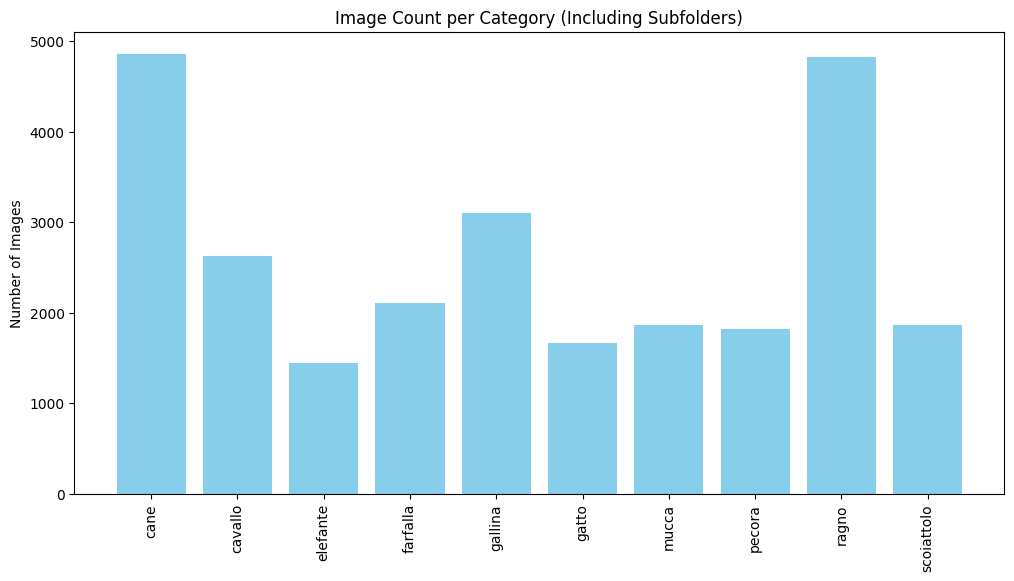

In [6]:
plt.figure(figsize=(12, 6))
plt.bar(image_counts.keys(), image_counts.values(), color='skyblue')
plt.xticks(rotation=90)
plt.ylabel("Number of Images")
plt.title("Image Count per Category (Including Subfolders)")
plt.show()

In [7]:
import os
import random
import shutil

def undersample_category(category_path, target_count):
    images = [f for f in os.listdir(category_path) if os.path.isfile(os.path.join(category_path, f))]
    if len(images) <= target_count:
        print(f"Skipping undersampling for {category_path}, already under target.")
        return
    to_remove = random.sample(images, len(images) - target_count)
    for img in to_remove:
        os.remove(os.path.join(category_path, img))
    print(f"Undersampled {category_path} to {target_count} images.")

def augment_image(img):
    # Random rotation (0°, 90°, 180°, 270°)
    angle = random.choice([0, 90, 180, 270])
    img = img.rotate(angle, expand=True)

    # Random horizontal flip
    if random.random() < 0.5:
        img = ImageOps.mirror(img)

    # Random brightness adjustment
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(random.uniform(0.8, 1.2))

    return img

def oversample_category(category_path, target_count):
    images = [f for f in os.listdir(category_path) if os.path.isfile(os.path.join(category_path, f))]
    if len(images) >= target_count:
        print(f"Skipping oversampling for {category_path}, already above target.")
        return
    i = 0
    while len(images) < target_count:
        src = random.choice(images)
        src_path = os.path.join(category_path, src)

        try:
            with Image.open(src_path) as img:
                img = img.convert("RGB")  # Ensure compatibility
                augmented_img = augment_image(img)

                name, ext = os.path.splitext(src)
                new_name = f"aug_{i}_{name}{ext}"
                new_path = os.path.join(category_path, new_name)

                augmented_img.save(new_path)
                images.append(new_name)
                i += 1
        except Exception as e:
            print(f"Error processing {src_path}: {e}")
    print(f"Oversampled {category_path} to {target_count} images with augmentation.")

In [8]:
# Define target count (you can change this)

target_per_category = 1000

# Apply to all categories
for category in sorted(image_counts.keys()):
    full_path = os.path.join(base_path, category)
    current_count = image_counts[category]

    print(f"\nProcessing category: {category} (current count: {current_count})")

    if current_count > target_per_category:
        undersample_category(full_path, target_per_category)
    elif current_count < target_per_category:
        oversample_category(full_path, target_per_category)
    else:
        print(f"{category} already balanced.")
        

'\ntarget_per_category = 1000\n\n# Apply to all categories\nfor category in sorted(image_counts.keys()):\n    full_path = os.path.join(base_path, category)\n    current_count = image_counts[category]\n\n    print(f"\nProcessing category: {category} (current count: {current_count})")\n\n    if current_count > target_per_category:\n        undersample_category(full_path, target_per_category)\n    elif current_count < target_per_category:\n        oversample_category(full_path, target_per_category)\n    else:\n        print(f"{category} already balanced.")\n        '

In [9]:
image_counts = get_image_counts(base_path)

# Remove the first key (subfolders) as per your comment
first_key = next(iter(image_counts))
#image_counts.pop(first_key)

categories = sorted(image_counts.keys())

print(categories)
# Display category image counts
print("\nImage counts per category (including sub-subfolders):")
for cat, count in image_counts.items():
    print(f"{cat}: {count}")

['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']

Image counts per category (including sub-subfolders):
cane: 4863
cavallo: 2623
elefante: 1446
farfalla: 2112
gallina: 3098
gatto: 1668
mucca: 1866
pecora: 1820
ragno: 4821
scoiattolo: 1862


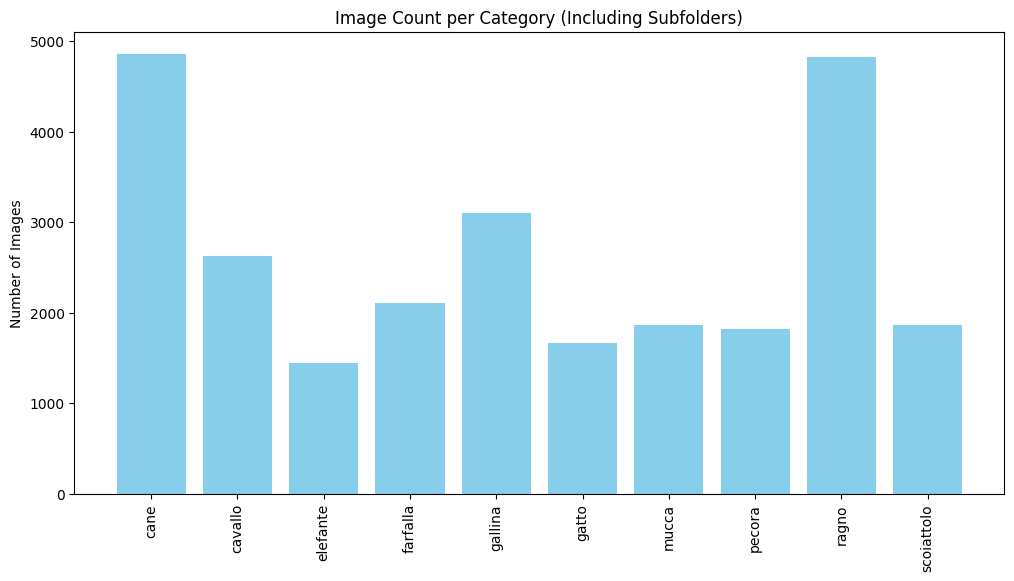

In [10]:
plt.figure(figsize=(12, 6))
plt.bar(image_counts.keys(), image_counts.values(), color='skyblue')
plt.xticks(rotation=90)
plt.ylabel("Number of Images")
plt.title("Image Count per Category (Including Subfolders)")
plt.show()

C:\Users\42190\PycharmProjects\NS_jupyter_2\raw-img\cane\OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg
C:\Users\42190\PycharmProjects\NS_jupyter_2\raw-img\cavallo\OIP---MGqQIhmz3OEPYP-46_xwHaFj.jpeg
C:\Users\42190\PycharmProjects\NS_jupyter_2\raw-img\elefante\e032b10b2df21c22d2524518b7444f92e37fe5d404b0144390f8c07aa5ecb6_640.jpg
C:\Users\42190\PycharmProjects\NS_jupyter_2\raw-img\farfalla\e030b20928e90021d85a5854ee454296eb70e3c818b413449df6c87ca3ed_640.jpg
C:\Users\42190\PycharmProjects\NS_jupyter_2\raw-img\gallina\10.jpeg
C:\Users\42190\PycharmProjects\NS_jupyter_2\raw-img\gatto\1.jpeg
C:\Users\42190\PycharmProjects\NS_jupyter_2\raw-img\mucca\OIP---lAIbDlHKmejDpqrXq6vAAAAA.jpeg
C:\Users\42190\PycharmProjects\NS_jupyter_2\raw-img\pecora\e032b5082ef61c22d2524518b7444f92e37fe5d404b0144390f8c078a0eabd_640.jpg
C:\Users\42190\PycharmProjects\NS_jupyter_2\raw-img\ragno\e034b90b20f11c22d2524518b7444f92e37fe5d404b0144390f8c47ba6ebb4_640.jpg
C:\Users\42190\PycharmProjects\NS_jupyter_2\raw-img\scoiattolo\OIP-

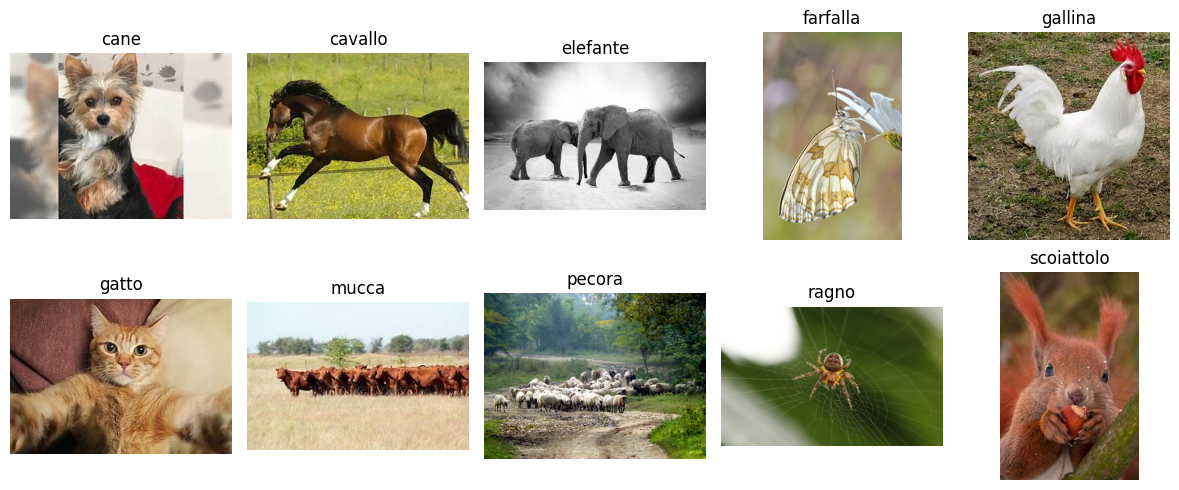

In [11]:


fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

# Iterate over the first 10 categories
for i, cat in enumerate(categories[:10]):
    cat_path = os.path.join(extract_path, cat)  # Fixing the path concatenation
    img_files = [f for f in os.listdir(cat_path) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
    if img_files:  # Ensure the category has images
        img_path = os.path.join(cat_path, img_files[0])
        img = Image.open(img_path)  # This should now work
        print(img_path)
        axes[i].imshow(img)
        axes[i].set_title(cat)
        axes[i].axis("off")

plt.tight_layout()
plt.show()

<h1> DataFrame preparatio </h1>
Berieme v úvahu iba png, jpeg, jpg <Br>
Pozeráme či RGB nieje náhodou skryté Greyscale <Br>
Nechávame iba RBG

In [12]:
def check_rgb_grayscale(img_path):
    """
    Check if the image is RGB and if Red, Green, and Blue channels are the same (grayscale).

    Parameters:
    - img_path: The path to the image.

    Returns:
    - True if the image is RGB and all channels are the same for all pixels.
    """
    with Image.open(img_path) as img:
        # Ensure the image is in RGB mode
        if img.mode != 'RGB':
            #print(f"The image {img_path} is not in RGB mode. It's in {img.mode} mode.")
            return False

        # Convert image to numpy array for easy manipulation (optional but faster for large images)
        pixels = img.load()  # This gives you access to pixel data

        # Check if all RGB values are the same for each pixel
        for y in range(img.height):
            for x in range(img.width):
                r, g, b = pixels[x, y]  # Get RGB values for the pixel
                if r != g or g != b:  # If Red, Green, and Blue are not the same
                    return False  # Found a non-grayscale pixel, return False



        return True  # All pixels have the same R, G, B values, so the image is grayscale

In [13]:
label_dict = {
    "cane": 0,
     "cavallo": 1 ,
     "elefante": 2 ,
     "farfalla": 3 ,
     "gallina": 4 ,
     "gatto": 5 ,
     "mucca": 6 ,
     "pecora": 7,
     "ragno" : 8,
     "scoiattolo": 9,
    # Add more class mappings if needed
}



In [14]:
def is_rgb_image(img_path):
    try:
        with Image.open(img_path) as img:
            return img.mode == 'RGB'  # Check if the image mode is RGB
    except Exception as e:
        print(f"Error opening image {img_path} for mode check: {e}")
        return False

# Function to process an individual image (no need to open the image fully)
def process_image(img_path):
    try:
        # Check if the image is RGB
        if not is_rgb_image(img_path):
            return None  # Skip non-RGB images

        # Get the size of the image file in bytes
        image_size = os.path.getsize(img_path)

        # Open image just for size and format (without loading the pixels)
        with Image.open(img_path) as img:
            # Get image properties (width, height, type)
            width, height = img.size
            image_type = img.format  # JPEG, PNG, etc.

        # Extract the subdirectory name from the root path
        subdirectory_name = os.path.basename(os.path.dirname(img_path))
        label = label_dict.get(subdirectory_name, -1)  # Use -1 for unknown classes

        return {
            'subdirectory_name': subdirectory_name,
            'image_name': os.path.basename(img_path),
            'image_size_bytes': image_size,
            'width': width,
            'height': height,
            'image_type': image_type,
            'label': label,
        }

    except Exception as e:
        print(f"Error processing image {img_path}: {e}")
        return None

# Function to process all images sequentially (no parallel processing)
def process_images_sequentially(dataset_path):
    image_data = []

    # List all image files
    image_paths = []
    for root, dirs, files in os.walk(dataset_path):
        for img_file in files:
            if img_file.lower().endswith(('png', 'jpg', 'jpeg')):
                img_path = os.path.join(root, img_file)
                image_paths.append(img_path)

    # Process images sequentially
    for idx, img_path in enumerate(image_paths):
        result = process_image(img_path)
        if result:
            image_data.append(result)

        # Print every 1000 processed images
        if (idx + 1) % 1000 == 0:
            print(f"Processed {idx + 1} images...")

        if (idx + 1) % 10000 == 0:
            gc.collect()
    return image_data

# Run the sequential process
dataset_path = extract_path  # Replace with your path
image_data = process_images_sequentially(dataset_path)

# Convert the collected data into a pandas DataFrame
image_df = pd.DataFrame(image_data)

# Display the first few rows of the DataFrame to check the data
print(image_df.head())

Processed 1000 images...
Processed 2000 images...
Processed 3000 images...
Processed 4000 images...
Processed 5000 images...
Processed 6000 images...
Processed 7000 images...
Processed 8000 images...
Processed 9000 images...
Processed 10000 images...
Processed 11000 images...
Processed 12000 images...
Processed 13000 images...
Processed 14000 images...
Processed 15000 images...
Processed 16000 images...
Processed 17000 images...
Processed 18000 images...
Processed 19000 images...
Processed 20000 images...
Processed 21000 images...
Processed 22000 images...
Processed 23000 images...
Processed 24000 images...
Processed 25000 images...
Processed 26000 images...
  subdirectory_name                           image_name  image_size_bytes  \
0              cane      OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg              9451   
1              cane  OIP---A27bIBcUgX1qkbpZOPswHaFS.jpeg              9334   
2              cane  OIP---cByAiEbIxIAleGo9AqOQAAAA.jpeg              8966   
3              cane  

In [15]:
image_df.to_csv('my_data.csv', index=False)

In [16]:
image_df = pd.read_csv('my_data.csv')

# Display to verify
print(image_df)
dataset_path = extract_path

      subdirectory_name                           image_name  \
0                  cane      OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg   
1                  cane  OIP---A27bIBcUgX1qkbpZOPswHaFS.jpeg   
2                  cane  OIP---cByAiEbIxIAleGo9AqOQAAAA.jpeg   
3                  cane  OIP---ZIdwfUcJeVxnh47zppcQHaFj.jpeg   
4                  cane  OIP---ZRsOF7zsMqhW30WeF8-AHaFj.jpeg   
...                 ...                                  ...   
26123        scoiattolo  OIP-_U7JiIoYjbWPqmmmmdsvJwHaF5.jpeg   
26124        scoiattolo  OIP-_VBkNQd_MZI4xoemUb-FtAHaE7.jpeg   
26125        scoiattolo  OIP-_WyHKgREia-4VijlL6DNswHaFj.jpeg   
26126        scoiattolo  OIP-_xFGMN0UbYduHdiXQ1maZAHaIF.jpeg   
26127        scoiattolo  OIP-_XkUFCI2duAyKDD9utKQzgHaFc.jpeg   

       image_size_bytes  width  height image_type  label  
0                  9451    300     225       JPEG      0  
1                  9334    300     214       JPEG      0  
2                  8966    153     300       JPEG     

In [17]:
def get_unique_counts(df, column_name):
    """
    This function takes a DataFrame and a column name,
    and returns a dictionary with unique values in the column and their counts.

    Parameters:
    - df: The input DataFrame containing the data.
    - column_name: The column name to get unique values and counts from.

    Returns:
    - A dictionary with unique values as keys and their counts as values.
    """
    unique_counts = df[column_name].value_counts().to_dict()
    return unique_counts

In [18]:
color_mode_counts = get_unique_counts(image_df, 'height')

# Print the counts for each color mode
print("\nColor mode counts:")
for color_mode, count in color_mode_counts.items():
    print(f"{color_mode}: {count}")


Color mode counts:
300: 4870
225: 4401
200: 3295
169: 1049
426: 690
199: 586
240: 418
188: 395
221: 300
201: 290
214: 243
226: 241
194: 190
640: 187
202: 169
216: 145
210: 135
213: 129
220: 124
219: 120
480: 116
228: 114
209: 113
206: 113
223: 112
224: 112
218: 110
197: 109
230: 107
235: 106
180: 105
168: 104
232: 101
207: 100
211: 100
195: 99
204: 98
233: 96
251: 94
212: 90
237: 85
157: 82
215: 82
263: 81
150: 81
425: 80
190: 77
238: 73
245: 73
249: 72
222: 72
217: 72
267: 70
264: 69
208: 68
247: 68
187: 68
256: 67
185: 66
360: 66
229: 66
198: 66
252: 64
254: 64
192: 64
244: 63
242: 62
261: 61
283: 60
236: 59
231: 58
427: 57
203: 56
205: 55
257: 55
280: 53
250: 53
428: 53
259: 53
271: 52
246: 52
196: 52
273: 51
239: 50
266: 49
234: 49
241: 48
255: 48
299: 47
423: 47
177: 46
268: 46
183: 45
227: 45
278: 44
243: 42
287: 42
164: 42
276: 42
248: 42
193: 41
275: 41
253: 40
290: 40
285: 39
142: 39
294: 38
288: 37
178: 36
182: 36
160: 35
282: 35
260: 35
269: 34
292: 34
295: 34
176: 33
175: 

gatto
abdu-rahman-2934-unsplash.jpg
gatto
anete-lusina-609858-unsplash.jpg
gatto
anselmo-stevin-laksito-387930-unsplash.jpg
gatto
cat-mapper-max-ogden-204436-unsplash.jpg
gatto
cel-lisboa-73965-unsplash.jpg
gatto
chinda-sam-164936-unsplash.jpg
gatto
chinda-sam-413882-unsplash.jpg
gatto
christian-wright-386668-unsplash.jpg
gatto
erik-jan-leusink-126918-unsplash.jpg
gatto
erik-jan-leusink-144775-unsplash.jpg
gatto
erik-jan-leusink-180382-unsplash.jpg
gatto
erik-jan-leusink-378147-unsplash.jpg
gatto
erik-jan-leusink-427699-unsplash.jpg
gatto
erik-jan-leusink-561776-unsplash.jpg
gatto
freddie-marriage-40645-unsplash.jpg
gatto
hannah-troupe-349131-unsplash.jpg
gatto
jannik-selz-335261-unsplash.jpg
gatto
jonas-vincent-2717-unsplash.jpg
gatto
jose-ros-photo-388605-unsplash.jpg
gatto
josh-couch-475167-unsplash.jpg
gatto
kamonnat-onnom-106416-unsplash.jpg
gatto
kari-shea-471277-unsplash.jpg
gatto
kevin-knezic-254586-unsplash.jpg
gatto
koen-eijkelenboom-353684-unsplash.jpg
gatto
kristin-lopez-41

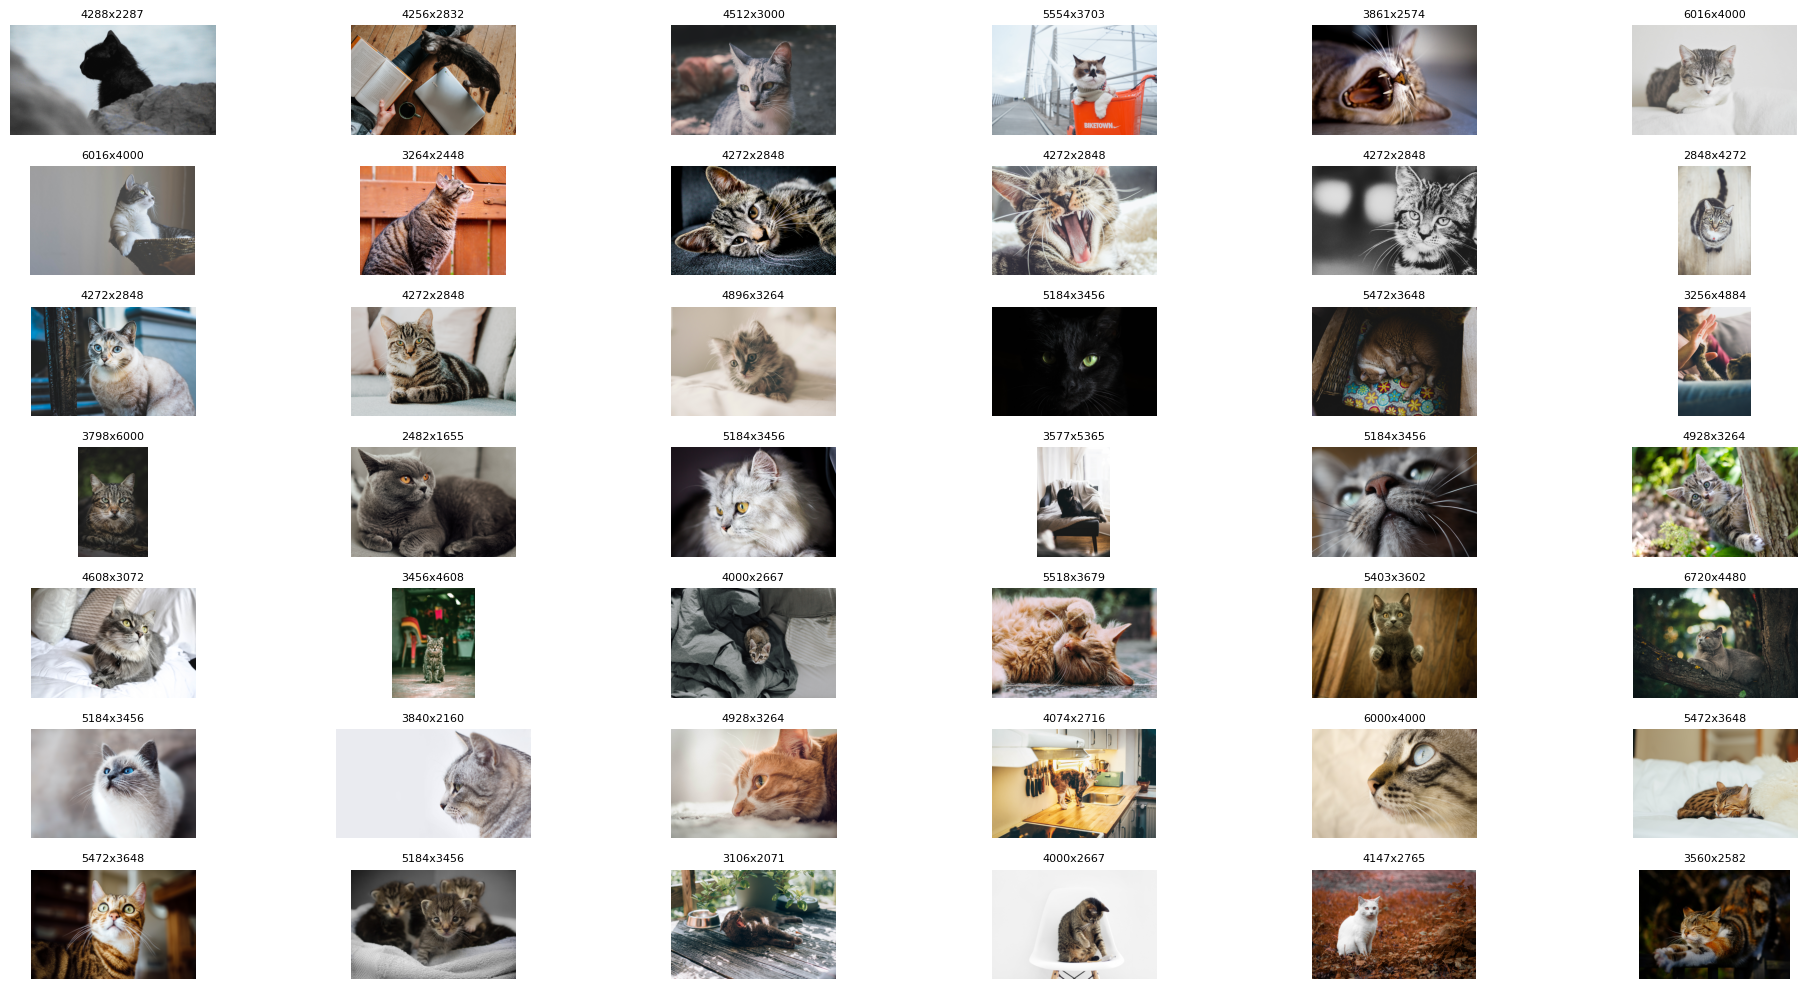

In [19]:
big_images = image_df[(image_df['width'] > 1000) | (image_df['height'] > 1000)]

# Select first 50 to display
big_images = big_images.head(50)

# Create a 5x10 grid
fig, axes = plt.subplots(7, 6, figsize=(20, 10))
axes = axes.flatten()

for i, (_, row) in enumerate(big_images.iterrows()):
    if i >= len(axes):
        break

    subdir = row['subdirectory_name'].strip()
    print(subdir)
    filename = row['image_name']
    print(filename)
    full_path = os.path.join(my_dir, extract_path, subdir, filename)

    if os.path.exists(full_path):
        try:
            img = Image.open(full_path)

            # Resize image to 25% of original size
            new_size = (img.width // 4, img.height // 4)
            img = img.resize(new_size)

            axes[i].imshow(img)
            axes[i].set_title(f"{row['width']}x{row['height']}", fontsize=8)
            axes[i].axis("off")

        except Exception as e:
            print(f"Error loading image {full_path}: {e}")
            axes[i].axis("off")
            axes[i].set_title("Error")
    else:
        print(f"Missing file: {full_path}")
        axes[i].axis("off")
        axes[i].set_title("Missing")

plt.tight_layout()
plt.show()

<h1> Code starts here</h1>

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torchvision import models
from tqdm import tqdm
import os
from tqdm import tqdm

In [21]:
params = {
    'batch_size': 32,
    'learning_rate': 1e-3,
    'num_epochs': 10,
    'img_size': 128,
    'train_val_split': 0.8,
    'num_classes': 2,  # Change based on your classes
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}


In [22]:
image_df['image_path'] = image_df.apply(lambda row: os.path.join(dataset_path, row['subdirectory_name'], row['image_name']), axis=1)

# Shuffle the dataset (in-place)
image_df = image_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Manually splitting the data
train_size = int(0.8 * len(image_df))  # 80% for training
val_size = int(0.1 * len(image_df))    # 10% for validation
test_size = len(image_df) - train_size - val_size  # Remaining 10% for testing

train_df = image_df[:train_size]
val_df = image_df[train_size:train_size + val_size]
test_df = image_df[train_size + val_size:]

print(f"Training data size: {len(train_df)}")
print(f"Validation data size: {len(val_df)}")
print(f"Test data size: {len(test_df)}")

print(train_df.head())

Training data size: 20902
Validation data size: 2612
Test data size: 2614
  subdirectory_name                           image_name  image_size_bytes  \
0             ragno  OIP-iJAyy_puzMN2v-189vEsUwHaE8.jpeg             19351   
1           cavallo  OIP-PfzazZlyqJs4e-CIlPrQOAHaFj.jpeg             14429   
2           gallina                             607.jpeg             22977   
3           cavallo  OIP-AHSrAWtCAg6eLf1ulS9sZwHaE7.jpeg             13718   
4             ragno  OIP-Yd9Y4FzpKizjhvunnkQx9QHaIH.jpeg             10923   

   width  height image_type  label  \
0    300     200       JPEG      8   
1    300     225       JPEG      1   
2    300     225       JPEG      4   
3    300     200       JPEG      1   
4    274     300       JPEG      8   

                                          image_path  
0  C:\Users\42190\PycharmProjects\NS_jupyter_2\ra...  
1  C:\Users\42190\PycharmProjects\NS_jupyter_2\ra...  
2  C:\Users\42190\PycharmProjects\NS_jupyter_2\ra...  
3  C:\Us

In [23]:
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        #print("1")
        #print(img_path)
        label = self.dataframe.iloc[idx]['label']

        # Load image
        image = Image.open(img_path)

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        # Convert label to tensor
        label = torch.tensor(label, dtype=torch.long)

        return image, label

In [24]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images to a fixed size 128 normal, 224 for mobilenet
    transforms.ToTensor(),          # Convert image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Normalize with ImageNet means & std
])

In [25]:
train_dataset = ImageDataset(train_df, transform=transform)
val_dataset = ImageDataset(val_df, transform=transform)
test_dataset = ImageDataset(test_df, transform=transform)

# Create DataLoader instances for each split
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(train_loader.num_workers)


0


In [26]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, 1, 1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, 1, 1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(128 * 16 * 16, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))

        x = x.view(-1, 128 * 16 * 16)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [27]:
def evaluate_model(model, val_loader, device='cuda', epoch=None):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    stats_val = {"loss_val": 0.0, "acc_val": 0.0}
    num_batches = len(val_loader)

    print(f"\n🧪 Evaluating Epoch {epoch}")
    with torch.no_grad():
        with tqdm(val_loader, desc=f"Val Epoch {epoch}", leave=False, dynamic_ncols=True) as progress:
            for x, y in progress:
                x, y = x.to(device), y.to(device)
                y_hat = model(x)
                loss = criterion(y_hat, y)

                stats_val["loss_val"] += loss.item() / num_batches
                stats_val["acc_val"] += compute_accuracy(y_hat, y) / num_batches
                progress.set_postfix({k: f"{v:.3f}" for k, v in stats_val.items()})

    print(f"✅ Val Epoch {epoch} completed | Loss: {stats_val['loss_val']:.4f}, Acc: {stats_val['acc_val']*100:.2f}%")
    if epoch is not None:
        wandb.log({
            "epoch": epoch,
            "val_loss": round(stats_val["loss_val"], 4),
            "val_accuracy": round(stats_val["acc_val"] * 100, 2)
        })

In [28]:
from tqdm import tqdm

def compute_accuracy(y_hat, y):
    _, predicted = torch.max(y_hat, 1)
    correct = (predicted == y).sum().item()
    return correct / y.size(0)

def train_model(model, train_loader, val_loader, num_epochs=10, learning_rate=0.001, device='cuda'):
    model.to(device)
    criterion = nn.CrossEntropyLoss()

    #weights = torch.tensor([1.0, 0.5, 2.0])

    # Define the loss function with weights
    #criterion = nn.CrossEntropyLoss(weight=weights)


        # Automatically detect if using MobileNet, ResNet, or custom model
    if hasattr(model, 'fc'):
        # ResNet-style
        optimizer = torch.optim.Adam(model.fc.parameters(), lr=learning_rate)
    elif hasattr(model, 'classifier'):
        # MobileNet-style
        optimizer = torch.optim.Adam(model.classifier.parameters(), lr=learning_rate)
    else:
        # Custom model like SimpleCNN
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):
        model.train()
        stats_train = {"loss_train": 0.0, "acc_train": 0.0}
        num_batches = len(train_loader)

        print(f"\n🔁 Training Epoch {epoch+1}/{num_epochs}")
        with tqdm(train_loader, desc=f"Train Epoch {epoch+1}", leave=False, dynamic_ncols=True) as progress:
            for x, y in progress:
                x, y = x.to(device), y.to(device)

                optimizer.zero_grad()
                y_hat = model(x)
                loss = criterion(y_hat, y)
                loss.backward()
                optimizer.step()

                stats_train["loss_train"] += loss.item() / num_batches
                stats_train["acc_train"] += compute_accuracy(y_hat, y) / num_batches
                progress.set_postfix({k: f"{v:.3f}" for k, v in stats_train.items()})

        print(f"✔️ Train Epoch {epoch+1} completed | Loss: {stats_train['loss_train']:.4f}, Acc: {stats_train['acc_train']*100:.2f}%")
        evaluate_model(model, val_loader, device=device, epoch=epoch+1)
        
        wandb.log({
            "epoch": epoch + 1,
            "train_loss": round(stats_train['loss_train'], 4),
            "train_accuracy": round(stats_train['acc_train'] * 100, 2)
        })

    wandb.finish()
        

In [29]:
num_classes = len(label_dict)  # Number of classes
#model of neural network
model = SimpleCNN(num_classes=num_classes)
#model = models.resnet18(pretrained = True)
#model = models.mobilenet_v2(pretrained=True)
# Freeze all layers so only the classifier is trained
'''
for param in model.parameters():
    param.requires_grad = False
'''
# Replace the final fully connected layer
#model.fc = nn.Linear(model.fc.in_features, num_classes)
#model.classifier[1] = nn.Linear(model.last_channel, num_classes)
print(f"Number of classes {num_classes}")
# Set the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Print which device is being used
if device.type == 'cuda':
    print(f"Training on GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Training on CPU")

Number of classes 10
Training on CPU


In [31]:
wandb.init(
    project="test",  # Replace with your actual W&B project
    config={
        "epochs": 10,
        "learning_rate": 0.001,
        "batch_size": train_loader.batch_size,
        "architecture": "SimpleCNN"
    }
)

# Train the model
train_model(model, train_loader , val_loader, num_epochs=10, learning_rate=0.001, device=device)


# Evaluate on the test set
evaluate_model(model, test_loader, device=device)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: farminmansk (farminmansk-fiit-stu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



🔁 Training Epoch 1/10


✔️ Train Epoch 1 completed | Loss: 2.1411, Acc: 35.20%

🧪 Evaluating Epoch 1


✅ Val Epoch 1 completed | Loss: 1.5467, Acc: 46.08%

🔁 Training Epoch 2/10


✔️ Train Epoch 2 completed | Loss: 1.4361, Acc: 49.66%

🧪 Evaluating Epoch 2


...

✔️ Train Epoch 10 completed | Loss: 0.4053, Acc: 85.83%

🧪 Evaluating Epoch 10


✅ Val Epoch 10 completed | Loss: 1.1290, Acc: 69.51%


epoch,▁▁▂▂▃▃▃▃▄▄▅▅▆▆▆▆▇▇██
train_accuracy,▁▃▄▅▆▆▇▇██
train_loss,█▅▄▄▃▃▂▂▁▁
val_accuracy,▁▃▅▆▅▇▇▇██
val_loss,█▆▃▂▃▁▂▃▂▂
epoch,10
train_accuracy,85.83
train_loss,0.4053
val_accuracy,69.51
val_loss,1.129



🧪 Evaluating Epoch None


✅ Val Epoch None completed | Loss: 1.1053, Acc: 70.14%
